In [2]:
pip install matplotlib


  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.3 MB 9.5 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.3 MB 9.4 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 9.4 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.9 MB/s  0:00:01
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   --------------------------- ------------ 1.6/2.3 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.0 MB/s  0:00:00
Usin


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


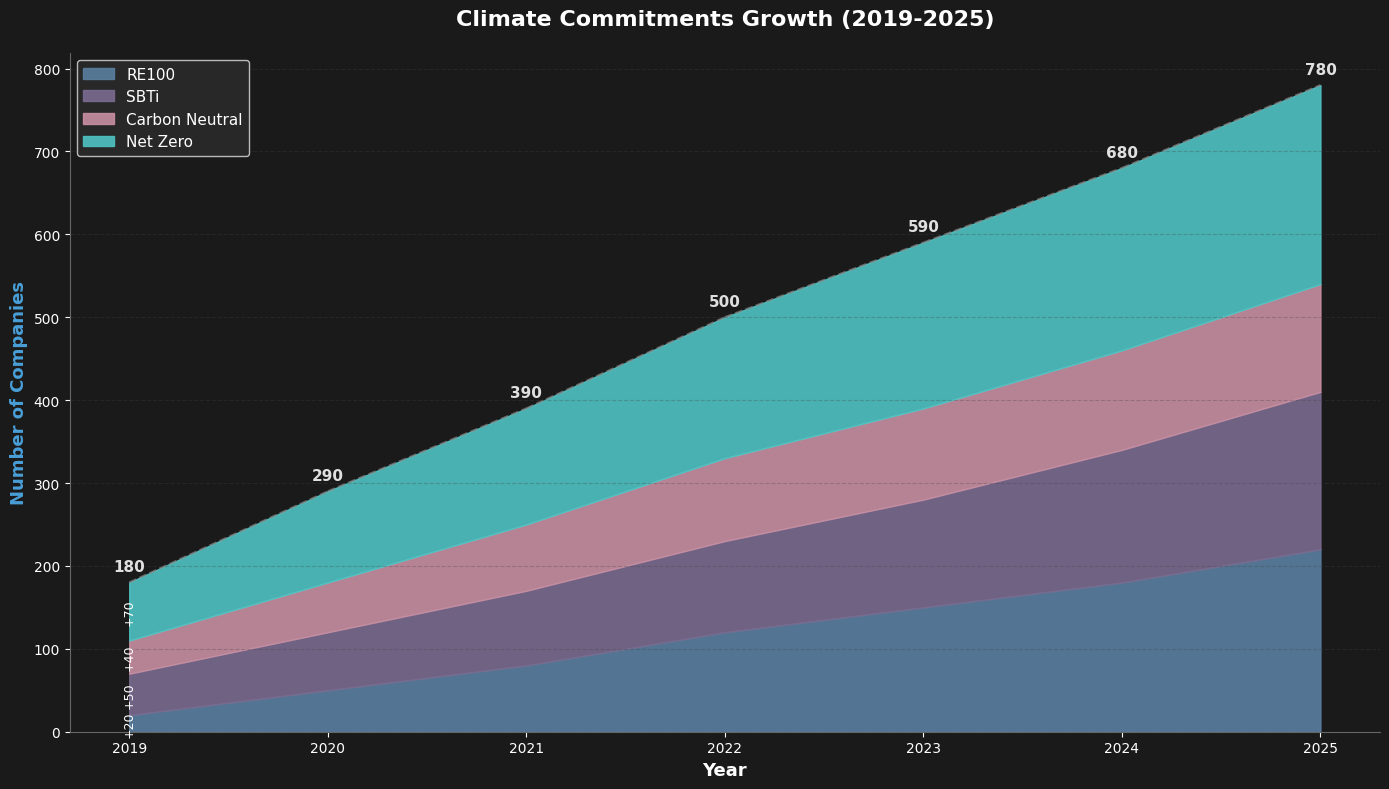

Chart saved as 'climate_commitments_waterfall.png'

Totals by year:
  2019: 180
  2020: 290
  2021: 390
  2022: 500
  2023: 590
  2024: 680
  2025: 780


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Set up styling
plt.rcParams['figure.facecolor'] = '#1a1a1a'  # Dark background
plt.rcParams['axes.facecolor'] = '#1a1a1a'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#444444'

# Data - adjust these values to match your actual data
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Example data for each category (replace with your actual data)
# These should be the counts for each commitment type per year
re100 = [20, 50, 80, 120, 150, 180, 220]  
sbti = [50, 70, 90, 110, 130, 160, 190]   
carbon_neutral = [40, 60, 80, 100, 110, 120, 130]  
net_zero = [70, 110, 140, 170, 200, 220, 240]  

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 8))

# Colors for each category (adjust to match your image)
color_re100 = '#5A7FA0'  # Blue-gray
color_sbti = '#7A6B8F'   # Purple-gray  
color_carbon = '#C88FA2' # Pink
color_net_zero = '#4FC3C3' # Cyan/turquoise

# Create stacked areas from bottom to top
ax.fill_between(years, 0, re100, 
                color=color_re100, alpha=0.9, label='RE100')

ax.fill_between(years, re100, 
                np.array(re100) + np.array(sbti),
                color=color_sbti, alpha=0.9, label='SBTi')

ax.fill_between(years, np.array(re100) + np.array(sbti),
                np.array(re100) + np.array(sbti) + np.array(carbon_neutral),
                color=color_carbon, alpha=0.9, label='Carbon Neutral')

ax.fill_between(years, 
                np.array(re100) + np.array(sbti) + np.array(carbon_neutral),
                np.array(re100) + np.array(sbti) + np.array(carbon_neutral) + np.array(net_zero),
                color=color_net_zero, alpha=0.9, label='Net Zero')

# Calculate totals for each year
totals = [sum(x) for x in zip(re100, sbti, carbon_neutral, net_zero)]

# Add diagonal connecting lines between year totals
for i in range(len(years) - 1):
    ax.plot([years[i], years[i+1]], [totals[i], totals[i+1]], 
            color='#888888', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

# Add total value labels on top
for i, (year, total) in enumerate(zip(years, totals)):
    ax.text(year, total + 10, str(total), 
            ha='center', va='bottom', fontsize=11, 
            fontweight='bold', color='#E0E0E0')

# Add category labels inside the first bar for reference
mid_year = years[0]
ax.text(mid_year, re100[0]/2, f'+{re100[0]}', 
        ha='center', va='center', fontsize=9, color='white', rotation=90)
ax.text(mid_year, re100[0] + sbti[0]/2, f'+{sbti[0]}', 
        ha='center', va='center', fontsize=9, color='white', rotation=90)
ax.text(mid_year, re100[0] + sbti[0] + carbon_neutral[0]/2, f'+{carbon_neutral[0]}', 
        ha='center', va='center', fontsize=9, color='white', rotation=90)
ax.text(mid_year, re100[0] + sbti[0] + carbon_neutral[0] + net_zero[0]/2, f'+{net_zero[0]}', 
        ha='center', va='center', fontsize=9, color='white', rotation=90)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Companies', fontsize=13, fontweight='bold', color='#4A9FD8')
ax.set_title('Climate Commitments Growth (2019-2025)', 
             fontsize=16, fontweight='bold', pad=20)

# Legend
ax.legend(loc='upper left', fontsize=11, framealpha=0.9, facecolor='#2a2a2a')

# Grid
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

# Set x-axis ticks
ax.set_xticks(years)
ax.set_ylim(bottom=0)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#666666')
ax.spines['bottom'].set_color('#666666')

plt.tight_layout()
plt.savefig('climate_commitments_waterfall.png', dpi=300, bbox_inches='tight', 
            facecolor='#1a1a1a', edgecolor='none')
plt.show()

print("Chart saved as 'climate_commitments_waterfall.png'")
print(f"\nTotals by year:")
for year, total in zip(years, totals):
    print(f"  {year}: {total}")

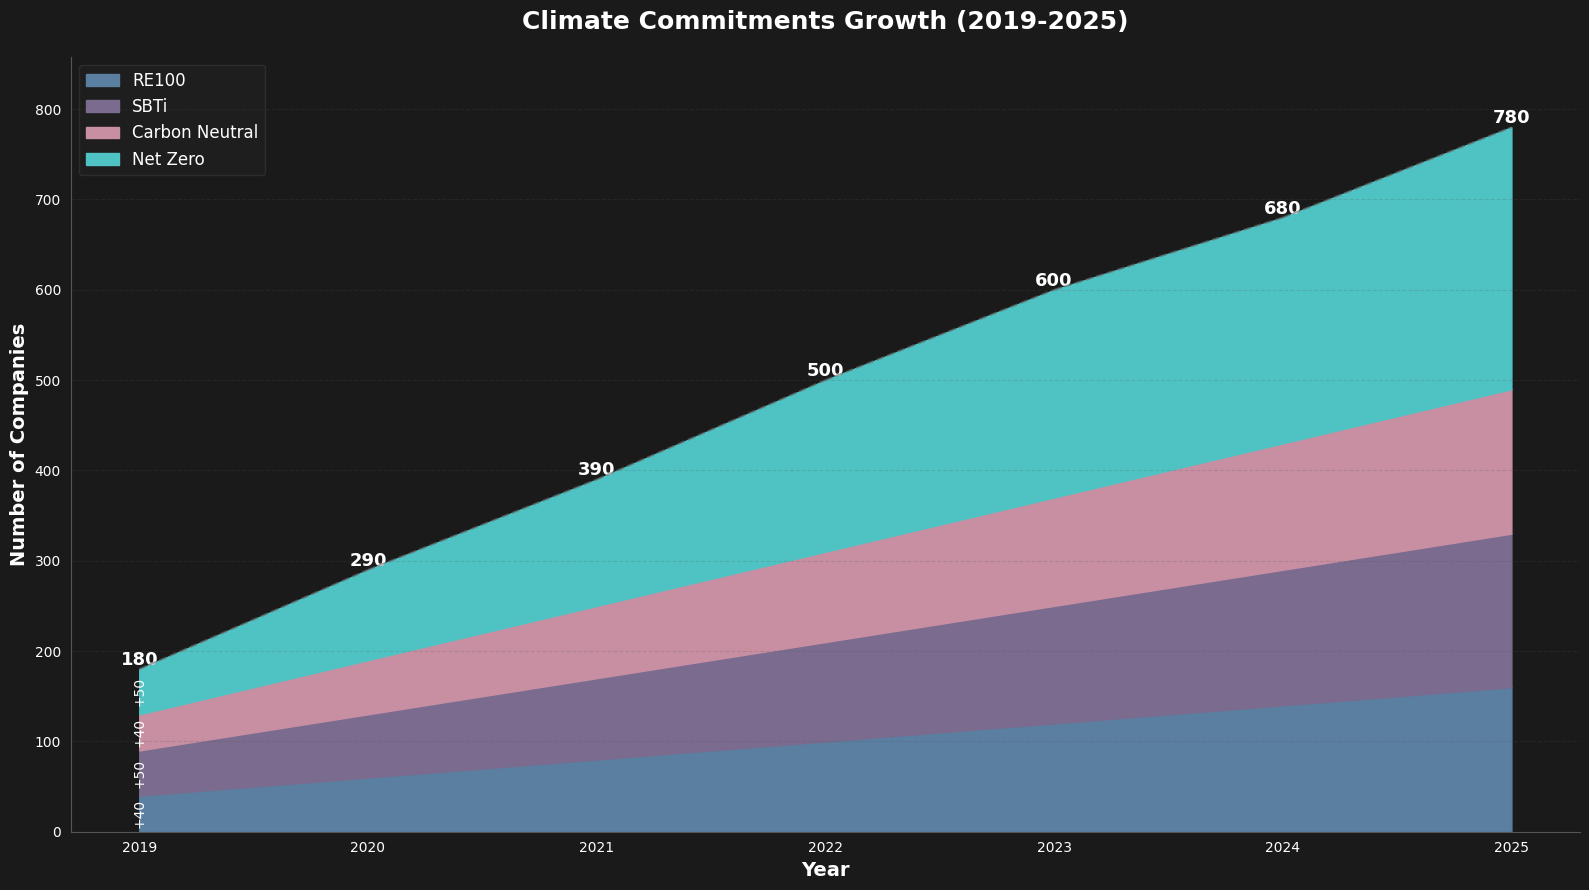

Chart saved as 'climate_commitments_waterfall_dark.png'

Totals by year:
  2019: 180
  2020: 290
  2021: 390
  2022: 500
  2023: 600
  2024: 680
  2025: 780


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Set up styling - DARK THEME like the first image
plt.rcParams['figure.facecolor'] = '#1a1a1a'  # Dark background
plt.rcParams['axes.facecolor'] = '#1a1a1a'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#444444'
plt.rcParams['font.family'] = 'sans-serif'

# Data - REPLACE WITH YOUR ACTUAL DATA
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Category data (adjust these to match your actual numbers)
re100 = [40, 60, 80, 100, 120, 140, 160]  
sbti = [50, 70, 90, 110, 130, 150, 170]   
carbon_neutral = [40, 60, 80, 100, 120, 140, 160]  
net_zero = [50, 100, 140, 190, 230, 250, 290]  

# Create figure
fig, ax = plt.subplots(figsize=(16, 9), facecolor='#1a1a1a')
ax.patch.set_facecolor('#1a1a1a')

# Colors matching the first image
color_re100 = '#5A7FA0'      # Blue-gray
color_sbti = '#7A6B8F'       # Purple-gray  
color_carbon = '#C88FA2'     # Pink
color_net_zero = '#4FC3C3'   # Cyan/turquoise

# Create stacked areas from bottom to top
ax.fill_between(years, 0, re100, 
                color=color_re100, alpha=1, label='RE100')

ax.fill_between(years, re100, 
                np.array(re100) + np.array(sbti),
                color=color_sbti, alpha=1, label='SBTi')

ax.fill_between(years, np.array(re100) + np.array(sbti),
                np.array(re100) + np.array(sbti) + np.array(carbon_neutral),
                color=color_carbon, alpha=1, label='Carbon Neutral')

ax.fill_between(years, 
                np.array(re100) + np.array(sbti) + np.array(carbon_neutral),
                np.array(re100) + np.array(sbti) + np.array(carbon_neutral) + np.array(net_zero),
                color=color_net_zero, alpha=1, label='Net Zero')

# Calculate totals
totals = [sum(x) for x in zip(re100, sbti, carbon_neutral, net_zero)]

# KEY FEATURE: Diagonal dashed lines connecting each year's total to the next
for i in range(len(years) - 1):
    ax.plot([years[i], years[i+1]], [totals[i], totals[i+1]], 
            color='#666666', linestyle='--', linewidth=1.5, alpha=0.6, zorder=5)

# Add total value labels on top of each year
for year, total in zip(years, totals):
    ax.text(year, total, str(total), 
            ha='center', va='bottom', fontsize=13, 
            fontweight='bold', color='white')

# Add increment labels inside the first bar (optional)
mid_year = years[0]
y_pos_re100 = re100[0]/2
y_pos_sbti = re100[0] + sbti[0]/2
y_pos_carbon = re100[0] + sbti[0] + carbon_neutral[0]/2
y_pos_net_zero = re100[0] + sbti[0] + carbon_neutral[0] + net_zero[0]/2

ax.text(mid_year, y_pos_re100, f'+{re100[0]}', 
        ha='center', va='center', fontsize=10, color='white', rotation=90)
ax.text(mid_year, y_pos_sbti, f'+{sbti[0]}', 
        ha='center', va='center', fontsize=10, color='white', rotation=90)
ax.text(mid_year, y_pos_carbon, f'+{carbon_neutral[0]}', 
        ha='center', va='center', fontsize=10, color='white', rotation=90)
ax.text(mid_year, y_pos_net_zero, f'+{net_zero[0]}', 
        ha='center', va='center', fontsize=10, color='white', rotation=90)

# Styling
ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Companies', fontsize=14, fontweight='bold')
ax.set_title('Climate Commitments Growth (2019-2025)', 
             fontsize=18, fontweight='bold', pad=20, color='white')

# Legend
ax.legend(loc='upper left', fontsize=12, framealpha=0.3, facecolor='#2a2a2a', edgecolor='#555555')

# Grid
ax.grid(True, alpha=0.2, linestyle='--', axis='y', color='#555555')

# X-axis
ax.set_xticks(years)
ax.set_ylim(bottom=0, top=max(totals) * 1.1)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

# Remove tick marks
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.savefig('climate_commitments_waterfall_dark.png', dpi=300, bbox_inches='tight', 
            facecolor='#1a1a1a', edgecolor='none')
plt.show()

print("Chart saved as 'climate_commitments_waterfall_dark.png'")
print(f"\nTotals by year:")
for year, total in zip(years, totals):
    print(f"  {year}: {total}")

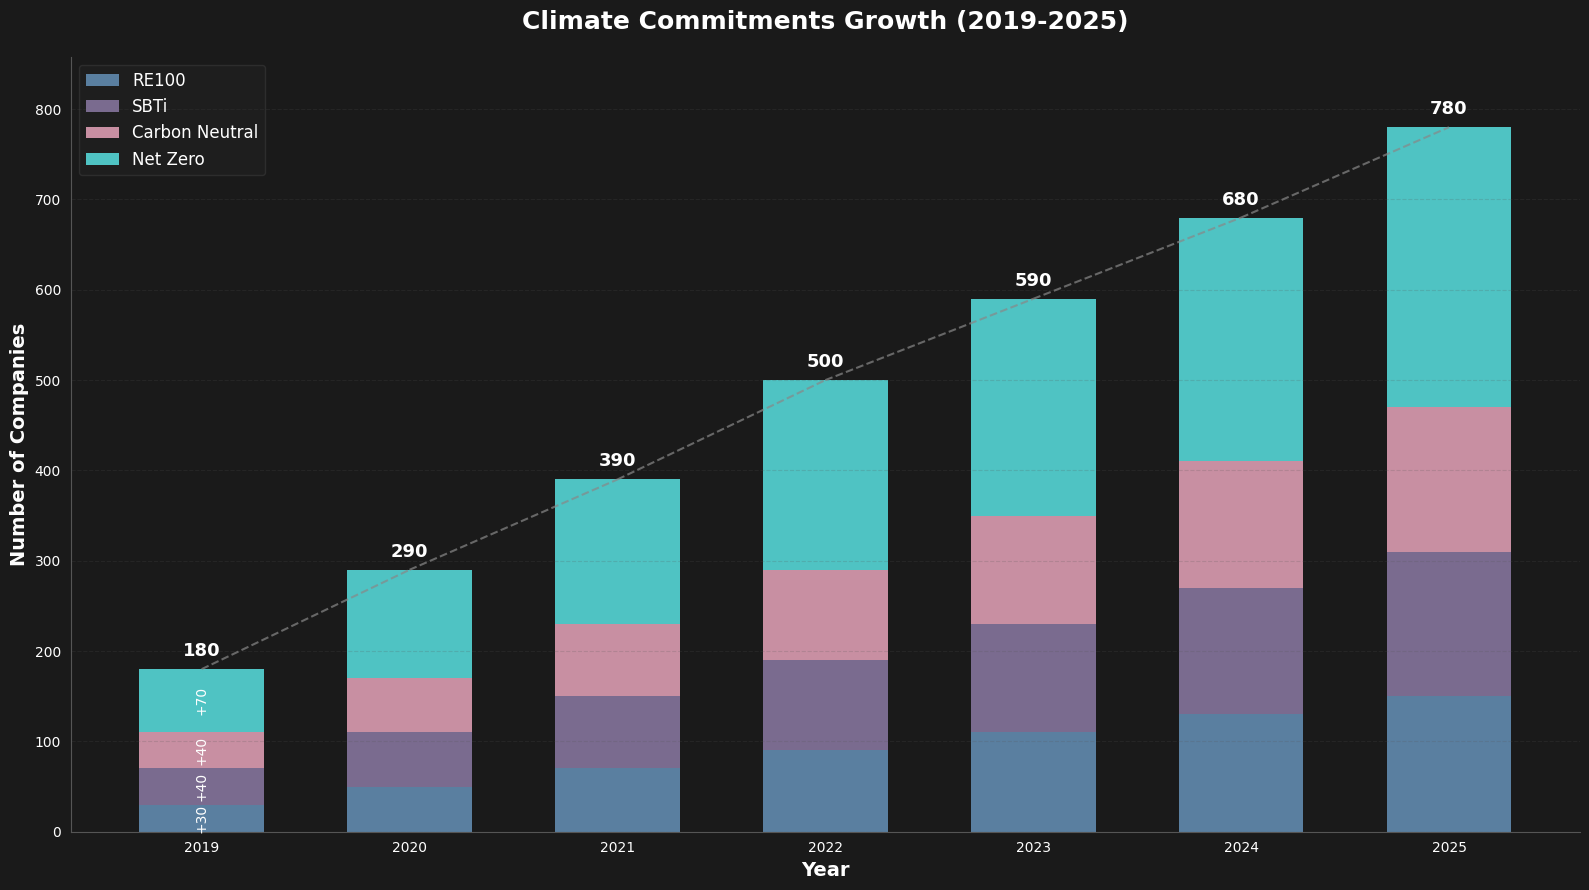

Chart saved as 'climate_commitments_stacked_bars.png'

Totals by year:
  2019: 180
  2020: 290
  2021: 390
  2022: 500
  2023: 590
  2024: 680
  2025: 780


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Set up styling - DARK THEME
plt.rcParams['figure.facecolor'] = '#1a1a1a'
plt.rcParams['axes.facecolor'] = '#1a1a1a'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#444444'
plt.rcParams['font.family'] = 'sans-serif'

# Data - REPLACE WITH YOUR ACTUAL DATA
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Category data (adjust these to match your actual numbers from the chart)
re100 = [30, 50, 70, 90, 110, 130, 150]  
sbti = [40, 60, 80, 100, 120, 140, 160]   
carbon_neutral = [40, 60, 80, 100, 120, 140, 160]  
net_zero = [70, 120, 160, 210, 240, 270, 310]  

# Create figure
fig, ax = plt.subplots(figsize=(16, 9), facecolor='#1a1a1a')
ax.patch.set_facecolor('#1a1a1a')

# Colors matching the first image
color_re100 = '#5A7FA0'      # Blue-gray
color_sbti = '#7A6B8F'       # Purple-gray  
color_carbon = '#C88FA2'     # Pink
color_net_zero = '#4FC3C3'   # Cyan/turquoise

# Bar width and positions
bar_width = 0.6
x_pos = np.arange(len(years))

# Create STACKED BARS
ax.bar(x_pos, re100, bar_width, color=color_re100, alpha=1, label='RE100')

ax.bar(x_pos, sbti, bar_width, bottom=re100, 
       color=color_sbti, alpha=1, label='SBTi')

ax.bar(x_pos, carbon_neutral, bar_width, 
       bottom=np.array(re100) + np.array(sbti),
       color=color_carbon, alpha=1, label='Carbon Neutral')

ax.bar(x_pos, net_zero, bar_width, 
       bottom=np.array(re100) + np.array(sbti) + np.array(carbon_neutral),
       color=color_net_zero, alpha=1, label='Net Zero')

# Calculate totals
totals = [sum(x) for x in zip(re100, sbti, carbon_neutral, net_zero)]

# DIAGONAL DASHED LINES connecting the tops of bars
for i in range(len(x_pos) - 1):
    ax.plot([x_pos[i], x_pos[i+1]], [totals[i], totals[i+1]], 
            color='#888888', linestyle='--', linewidth=1.5, alpha=0.7, zorder=10)

# Add total value labels on top of each bar
for i, total in enumerate(totals):
    ax.text(x_pos[i], total + 10, str(total), 
            ha='center', va='bottom', fontsize=13, 
            fontweight='bold', color='white')

# Add increment labels inside the first bar
ax.text(x_pos[0], re100[0]/2, f'+{re100[0]}', 
        ha='center', va='center', fontsize=10, color='white', rotation=90)
ax.text(x_pos[0], re100[0] + sbti[0]/2, f'+{sbti[0]}', 
        ha='center', va='center', fontsize=10, color='white', rotation=90)
ax.text(x_pos[0], re100[0] + sbti[0] + carbon_neutral[0]/2, f'+{carbon_neutral[0]}', 
        ha='center', va='center', fontsize=10, color='white', rotation=90)
ax.text(x_pos[0], re100[0] + sbti[0] + carbon_neutral[0] + net_zero[0]/2, f'+{net_zero[0]}', 
        ha='center', va='center', fontsize=10, color='white', rotation=90)

# Styling
ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Companies', fontsize=14, fontweight='bold')
ax.set_title('Climate Commitments Growth (2019-2025)', 
             fontsize=18, fontweight='bold', pad=20, color='white')

# Legend
ax.legend(loc='upper left', fontsize=12, framealpha=0.3, 
          facecolor='#2a2a2a', edgecolor='#555555')

# Grid
ax.grid(True, alpha=0.2, linestyle='--', axis='y', color='#555555')

# X-axis
ax.set_xticks(x_pos)
ax.set_xticklabels(years)
ax.set_ylim(bottom=0, top=max(totals) * 1.1)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

# Remove tick marks
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.savefig('climate_commitments_stacked_bars.png', dpi=300, bbox_inches='tight', 
            facecolor='#1a1a1a', edgecolor='none')
plt.show()

print("Chart saved as 'climate_commitments_stacked_bars.png'")
print(f"\nTotals by year:")
for year, total in zip(years, totals):
    print(f"  {year}: {total}")